**Purpose:** Run Greedy and Simulated Annealing optimisation strategies to determine a geofence for AV.

**What is important for you in this notebook?**
- Brief algorithm description in Markdown
- Take a look into optimiser.py for detailed overwiew of an algorithm
- Definetelly go other each step of the contents to view resulted geofence and comaprison between greedy and Simulated Annealing

**Before the algorithm runs**, two revenue lookup tables are built from the trip data:

- revenue_lookup — {(pickup_block, dropoff_block): total_revenue}: raw pairwise revenue for every pickup/dropoff block combination observed in the trips.
- block_lookup — {block_id: {other_block_id: revenue}}: a re-indexed version of revenue_lookup keyed by individual block. For any block b, block_lookup[b] lists every other
block it has shared trip revenue with and how much.

These two structures serve two purposes:

1. **Seed selection** — before the algorithm starts, the revenue generated within each each block is computed as the sum of all  trips where block b is both the pickup or dropoff endpoint. Local maxima of for this revenue is serached for within CENTER_BBOX (coordinates of central box in which pick_up locations are spread) is a case when the revenue for the block is higher than the revenue of all its neighbours. After 5 local maximums are chosen at random as seeds.

2. **Marginal revenue during the algorithm** — every time the algorithm considers adding block b to the current zone, it uses block_lookup to compute the *marginal revenue*: the  extra revenue gained from all trips that pair b with any block already inside the zone. This is an O(1) lookup per candidate block, making the inner loop fast.
                                                                                                                                                                                            
**Both algorithms share the same loop structure:**

- **Seed** — start from one of the local maxima selected above.                                                                                                                        
- **Expand** — at each iteration, evaluate all blocks adjacent to the current zone and select one to add. Stops when no valid candidate exists or the area cap (15 sq km) is reached.
- **Swap** — when expansion stalls, try every (remove block b, add neighbour c) pair. Accept the swap if it increases revenue while keeping the zone connected and within the area   
cap. Repeats until no improving swap exists.                                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                                      
**The only difference** between the two modes is in the expand step, controlled by mode= in run_multi_start:                                                                       

- **Greedy (mode="greedy") — argmax:** always picks the adjacent block with the single highest positive marginal revenue. Deterministic and fast — the zone grows directly toward the best available block at every step. Cannot escape a local optimum once expansion and swapping both stall.
                                                                                                                                                                                        
- **SA (mode="sa") — softmax sampling:** instead of always picking the best block, candidates are sampled with probability proportional to exp(delta / T), where T is the current
temperature. At high temperature the distribution is near-uniform — the algorithm explores broadly and can accept worse blocks. As T decays geometrically each iteration (T ← T ×
cooling_rate), the distribution sharpens until at low temperature it is nearly identical to argmax. This lets SA escape local optima that greedy cannot leave, at the cost of some    
randomness early on.

SA has an **additional stopping condition** not present in greedy: the loop terminates early if the temperature drops below T_end = 1.0, even if max_iters has not been reached.   
Once the temperature is that low the softmax has collapsed to near-argmax and further iterations add no exploratory value.
                                                                                                                                                                                        
Based on a grid search over T_start ∈ {50, 150, 300, 600} and cooling_rate ∈ {0.98, 0.99, 0.995, 0.999} (§6 below), the best performing configuration is **T_start = 300,        
cooling_rate = 0.995**, which is used for all SA results in this notebook.

**What would be cool to consider in the future?**
- Somehow implement root optimisation for cars in the geofence generation structure, so that the form of geofence did not prevent cars for following the shortest paths.

**Contents**

1. Imports & load data
2. Revenue heatmap — unilateral revenue per block + seed locations
3. Run both algorithms
4. Per-seed comparison table
5. SA parameter sensitivity
6. Side-by-side map & final summary

## 1. Imports & load data

In [ ]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union

import src.config as cfg
from src.blocks import load_osm_data
from src.revenue import (
    build_revenue_lookup,
    build_block_lookup,
    compute_revenue,
    find_local_maxima_seeds,
)
from src.optimiser import build_adjacency, run_multi_start

# Data
blocks_main = gpd.read_file(cfg.FILTERED_BLOCKS_FILE) # This file is the output of `geofence_road_completness.ipynb` notebook, and contains all blocks with park/water coverage scores, but before any filtering.
trips       = pd.read_csv(cfg.TRIPS_ASSIGNED_FILE) # This file contains all trips with assigned block_id, and is the output of `assign_trips_to_blocks.ipynb` notebook.
_, roads    = load_osm_data(cfg.PBF_FILE, cfg.CENTER_BBOX, cfg.ROAD_TYPES, cfg.TARGET_CRS) # This is the raw OSM data, used only for visualisation purposes in this notebook.
print(f"Blocks: {len(blocks_main):,}  |  Trips: {len(trips):,}")

# Lookups 
revenue_lookup = build_revenue_lookup(trips) # This is a dict  {(pickup_block, dropoff_block): total_revenue}
block_lookup   = build_block_lookup(revenue_lookup) # re-indexes revenue_lookup into: {block_id: {other_block_id: revenue, ...}}
block_area_m2  = dict(zip(blocks_main["block_id"], blocks_main.geometry.area))  # {block_id: area_m²} — used to enforce the area cap during expand swap
total_rev      = compute_revenue(set(blocks_main["block_id"]), revenue_lookup) # upper bound: revenue if the entire block network were the geofence
print(f"Total convertible revenue: £{total_rev:,.2f}")

# Adjacency & seeds
adjacency = build_adjacency(blocks_main) # This is a dict {block_id: set(adjacent_block_ids)}, built from the blocks_main geodataframe, and is used to enforce connectivity in the optimiser.
seeds, _  = find_local_maxima_seeds(
    blocks_main, adjacency, block_lookup,
    k=cfg.N_SEEDS, center_bbox=cfg.CENTER_BBOX,
) # This is a list of seed block_ids, which are the starting points for the optimiser. They are selected as local maxima in revenue density (revenue per area), and are used to run multiple starts of the optimiser.
# A block is a local maximum if its unilateral revenue is ≥ every direct neighbour's. Only blocks whose centroid falls inside CENTER_BBOX are eligible — this excludes sparse outer areas where trip density is too low to   
# grow a meaningful geofence.   
print(f"Seeds: {seeds}")

Roads loaded:  47,041
Road types:    ['living_street', 'motorway', 'motorway_link', 'primary', 'primary_link', 'residential', 'secondary', 'secondary_link', 'tertiary', 'tertiary_link', 'trunk', 'trunk_link']
CRS:           EPSG:27700
Blocks: 29,480  |  Trips: 190,446
Total convertible revenue: £4,925,238.60


Building adjacency: 100%|██████████| 29480/29480 [00:14<00:00, 2048.90it/s]


Seed candidates restricted to center_bbox: 9,113 blocks
Local revenue maxima found: 1,134
  Seed 1: block_id=1819, unilateral_rev=£86,437.28
  Seed 2: block_id=4747, unilateral_rev=£58,762.40
  Seed 3: block_id=4830, unilateral_rev=£58,322.05
  Seed 4: block_id=23399, unilateral_rev=£56,177.70
  Seed 5: block_id=549, unilateral_rev=£31,011.94
Seeds: [1819, 4747, 4830, 23399, 549]


## 2. Revenue heatmap

Unilateral revenue per block — sum of all trip revenue where that block is
either the pickup or dropoff endpoint. Gives an immediate read on where
demand is concentrated before running either algorithm.
Seeds (S1–S5) are the local maxima used as starting points.

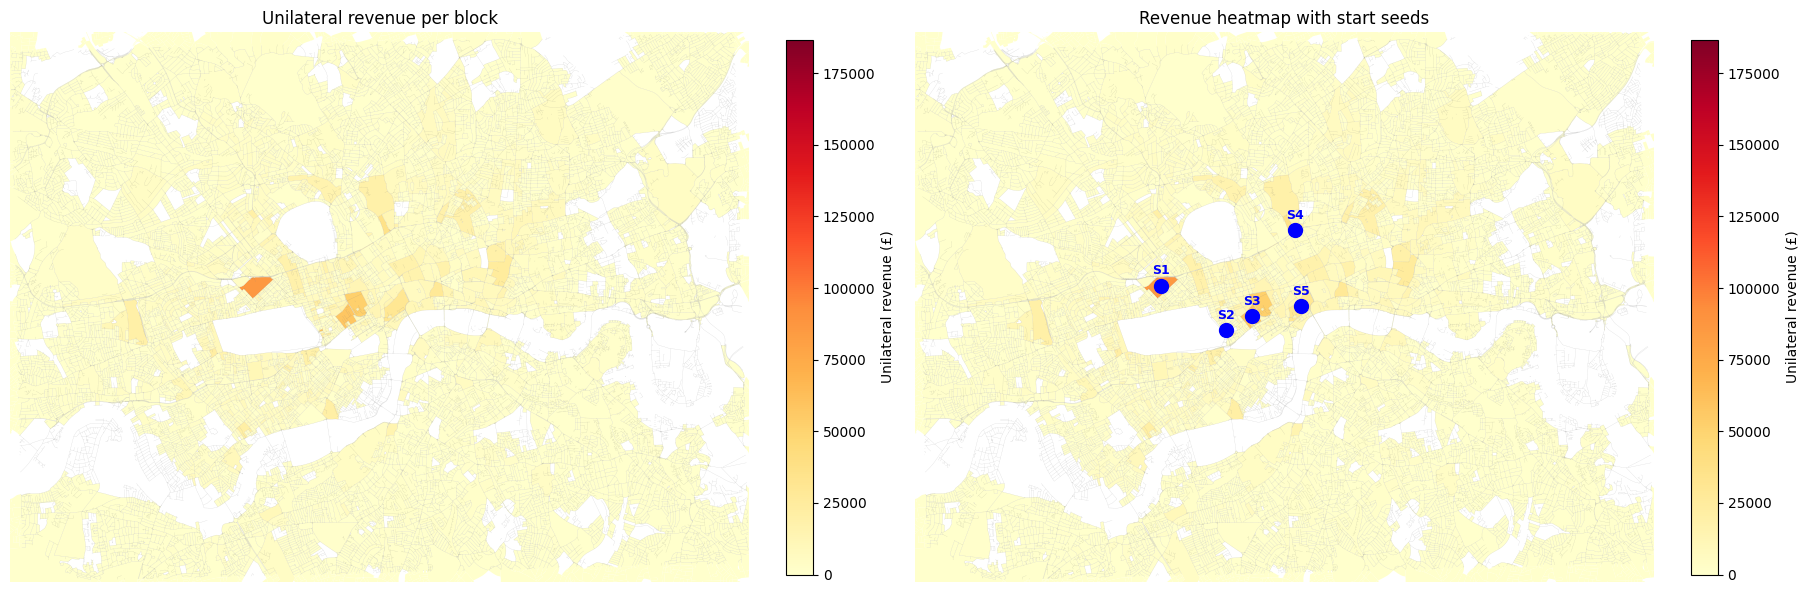

Top-5 blocks by unilateral revenue:
 block_id  unilateral_rev
    26741       186781.12
     1819        86437.28
     4747        58762.40
     4830        58322.05
    23399        56177.70


In [9]:
# ── Project CENTER_BBOX to map CRS ─────────────────────────────────────────────                                                                                                      
_bbox_proj = (
    gpd.GeoSeries(                                                                                                                                                                     
        [shapely_box(cfg.CENTER_BBOX[0], cfg.CENTER_BBOX[1],                                                                                                                           
                    cfg.CENTER_BBOX[2], cfg.CENTER_BBOX[3])],
        crs="EPSG:4326",                                                                                                                                                               
    )           
    .to_crs(cfg.TARGET_CRS)                                                                                                                                                            
    .iloc[0]    
)
xmin, ymin, xmax, ymax = _bbox_proj.bounds
                                                                                                                                                                                        
# ── Unilateral revenue per block ───────────────────────────────────────────────
unilateral_rev = {                                                                                                                                                                     
    int(bid): sum(block_lookup.get(int(bid), {}).values())
    for bid in blocks_main["block_id"]                                                                                                                                                 
}
blocks_main["unilateral_rev"] = (                                                                                                                                                      
    blocks_main["block_id"].map(unilateral_rev).fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)                                                                                                               

for ax in axes:                                                                                                                                                                        
    blocks_main.plot(
        ax=ax, column="unilateral_rev", cmap="YlOrRd",
        legend=True,                                                                                                                                                                   
        legend_kwds={"label": "Unilateral revenue (£)", "shrink": 0.6},
        edgecolor="none",                                                                                                                                                              
    )           
    roads.plot(ax=ax, linewidth=0.2, color="gray", alpha=0.3)
    ax.set_xlim(xmin, xmax)                                                                                                                                                            
    ax.set_ylim(ymin, ymax)
    ax.set_axis_off()                                                                                                                                                                  
                                                                                                                                                                                        
# Left: plain heatmap
axes[0].set_title("Unilateral revenue per block", fontsize=12)                                                                                                                         
                
# Right: heatmap with seeds marked
for i, bid in enumerate(seeds):
    pt = blocks_main.loc[                                                                                                                                                              
        blocks_main["block_id"] == bid, "geometry"
    ].centroid.values[0]                                                                                                                                                               
    axes[1].plot(pt.x, pt.y, "bo", markersize=10, zorder=5)
    axes[1].annotate(                                                                                                                                                                  
        f"S{i+1}", xy=(pt.x, pt.y + 300),
        fontsize=9, color="blue", ha="center", fontweight="bold",                                                                                                                      
    )                                                                                                                                                                                  
axes[1].set_title("Revenue heatmap with start seeds", fontsize=12)
                                                                                                                                                                                        
plt.show()      
print("Top-5 blocks by unilateral revenue:")
print(
    blocks_main[["block_id", "unilateral_rev"]]                                                                                                                                        
    .nlargest(5, "unilateral_rev")
    .to_string(index=False)                                                                                                                                                            
)              


## 3. Run both algorithms

Both calls use `run_multi_start` — the only difference is `mode=`.

In [3]:
# ── SA schedule ────────────────────────────────────────────────────────────────
T_START      = 300.0
T_END        = 1.0
COOLING_RATE = 0.995
SA_MAX_ITERS = 1000

print("=" * 55)
print("GREEDY")
print("=" * 55)
g_sel, g_rev, g_hist, g_seed, g_seed_df = run_multi_start(
    seeds, adjacency, block_lookup, block_area_m2,
    mode="greedy",
    max_area_sqkm=cfg.MAX_AREA_SQKM,
    max_iters=cfg.MAX_ITERS,
)

print("\n" + "=" * 55)
print("SIMULATED ANNEALING")
print("=" * 55)
sa_sel, sa_rev, sa_hist, sa_seed, sa_seed_df = run_multi_start(
    seeds, adjacency, block_lookup, block_area_m2,
    mode="sa",
    T_start=T_START, T_end=T_END, cooling_rate=COOLING_RATE,
    max_area_sqkm=cfg.MAX_AREA_SQKM,
    max_iters=SA_MAX_ITERS,
)

GREEDY

──────────────────────────────────────────────────
Run 1/5  seed=1819  mode=greedy
──────────────────────────────────────────────────
Seed 1819  rev=£9.55  greedy
Converged at iteration 9.
RESULT  seed=1819  blocks=9  best_rev=£147.88  final_rev=£147.88  area=0.32 sqkm

──────────────────────────────────────────────────
Run 2/5  seed=4747  mode=greedy
──────────────────────────────────────────────────
Seed 4747  rev=£5.13  greedy
Converged at iteration 1.
RESULT  seed=4747  blocks=1  best_rev=£5.13  final_rev=£5.13  area=0.00 sqkm

──────────────────────────────────────────────────
Run 3/5  seed=4830  mode=greedy
──────────────────────────────────────────────────
Seed 4830  rev=£23.11  greedy
Converged at iteration 215.
RESULT  seed=4830  blocks=215  best_rev=£172,227.80  final_rev=£172,227.80  area=15.00 sqkm

──────────────────────────────────────────────────
Run 4/5  seed=23399  mode=greedy
──────────────────────────────────────────────────
Seed 23399  rev=£0.00  greedy
Conv

## 4. Per-seed comparison table

In [5]:
comparison = (
    g_seed_df
    .rename(columns={"revenue": "greedy_rev", "n_blocks": "greedy_blocks"})
    .merge(
        sa_seed_df.rename(columns={"revenue": "sa_rev", "n_blocks": "sa_blocks"}),
        on="seed",
    )
)
comparison["delta_£"] = comparison["sa_rev"] - comparison["greedy_rev"]
comparison["delta_%"] = (100 * comparison["delta_£"] / comparison["greedy_rev"]).round(2)

# Highlight best seed per algorithm
print(f"Best greedy seed : {g_seed}")
print(f"Best SA seed     : {sa_seed}")
print()
print(comparison.to_string(index=False))

Best greedy seed : 4830
Best SA seed     : 1819

 seed  greedy_rev  greedy_blocks    sa_rev  sa_blocks   delta_£    delta_%
 1819      147.88              9 292624.98        297 292477.10  197780.02
 4747        5.13              1 207877.78        243 207872.65 4052098.44
 4830   172227.80            215 186646.49        226  14418.69       8.37
23399   131836.92            195 132349.91        190    512.99       0.39
  549   131836.92            195 157379.65        197  25542.73      19.37


## 5. SA parameter sensitivity — `T_start × cooling_rate` grid

Fixed to the best greedy seed so the schedule is the only variable.

Seed 4830  rev=£23.11  T_start=50.0  cooling=0.98
Temperature below T_end at iteration 195.
RESULT  seed=4830  blocks=195  best_rev=£154,129.38  final_rev=£154,129.38  area=15.00 sqkm
Seed 4830  rev=£23.11  T_start=50.0  cooling=0.99
Converged at iteration 196.
RESULT  seed=4830  blocks=195  best_rev=£131,836.92  final_rev=£131,836.92  area=15.00 sqkm
Seed 4830  rev=£23.11  T_start=50.0  cooling=0.995
Converged at iteration 196.
RESULT  seed=4830  blocks=195  best_rev=£131,836.92  final_rev=£131,836.92  area=15.00 sqkm
Seed 4830  rev=£23.11  T_start=50.0  cooling=0.999
Converged at iteration 198.
RESULT  seed=4830  blocks=196  best_rev=£132,100.13  final_rev=£132,100.13  area=15.00 sqkm
Seed 4830  rev=£23.11  T_start=150.0  cooling=0.98
Converged at iteration 226.
RESULT  seed=4830  blocks=226  best_rev=£177,553.04  final_rev=£177,553.04  area=15.00 sqkm
Seed 4830  rev=£23.11  T_start=150.0  cooling=0.99
Converged at iteration 211.
RESULT  seed=4830  blocks=211  best_rev=£170,117.99  f

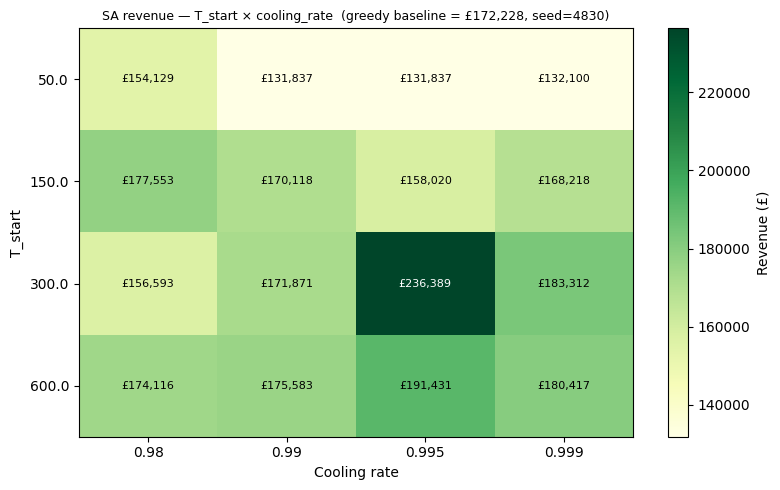

Best config: T_start=300.0  cooling=0.995  rev=£236,389.43


In [6]:
from src.optimiser import run_algorithm

T_STARTS      = [50.0, 150.0, 300.0, 600.0]
COOLING_RATES = [0.98, 0.99, 0.995, 0.999]

sens_rows = []
for t in T_STARTS:
    for cr in COOLING_RATES:
        sel, rev, _ = run_algorithm(
            g_seed, adjacency, block_lookup, block_area_m2,
            mode="sa",
            T_start=t, T_end=T_END, cooling_rate=cr,
            max_area_sqkm=cfg.MAX_AREA_SQKM,
            max_iters=SA_MAX_ITERS,
            random_seed=42,
        )
        sens_rows.append({"T_start": t, "cooling_rate": cr, "revenue": rev})

sens_df = pd.DataFrame(sens_rows)
pivot   = sens_df.pivot(index="T_start", columns="cooling_rate", values="revenue")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="YlGn", aspect="auto")
plt.colorbar(im, ax=ax, label="Revenue (£)")
ax.set_xticks(range(len(COOLING_RATES)))
ax.set_xticklabels(COOLING_RATES)
ax.set_yticks(range(len(T_STARTS)))
ax.set_yticklabels(T_STARTS)
ax.set_xlabel("Cooling rate")
ax.set_ylabel("T_start")

vmax = pivot.values.max()
for i in range(len(T_STARTS)):
    for j in range(len(COOLING_RATES)):
        val = pivot.values[i, j]
        ax.text(j, i, f"£{val:,.0f}", ha="center", va="center",
                fontsize=8, color="black" if val < vmax * 0.92 else "white")

ax.set_title(
    f"SA revenue — T_start × cooling_rate  "
    f"(greedy baseline = £{g_rev:,.0f}, seed={g_seed})",
    fontsize=9,
)
plt.tight_layout()
plt.show()

best = sens_df.loc[sens_df["revenue"].idxmax()]
print(f"Best config: T_start={best['T_start']}  "
      f"cooling={best['cooling_rate']}  rev=£{best['revenue']:,.2f}")

## 6. Side-by-side map & final summary

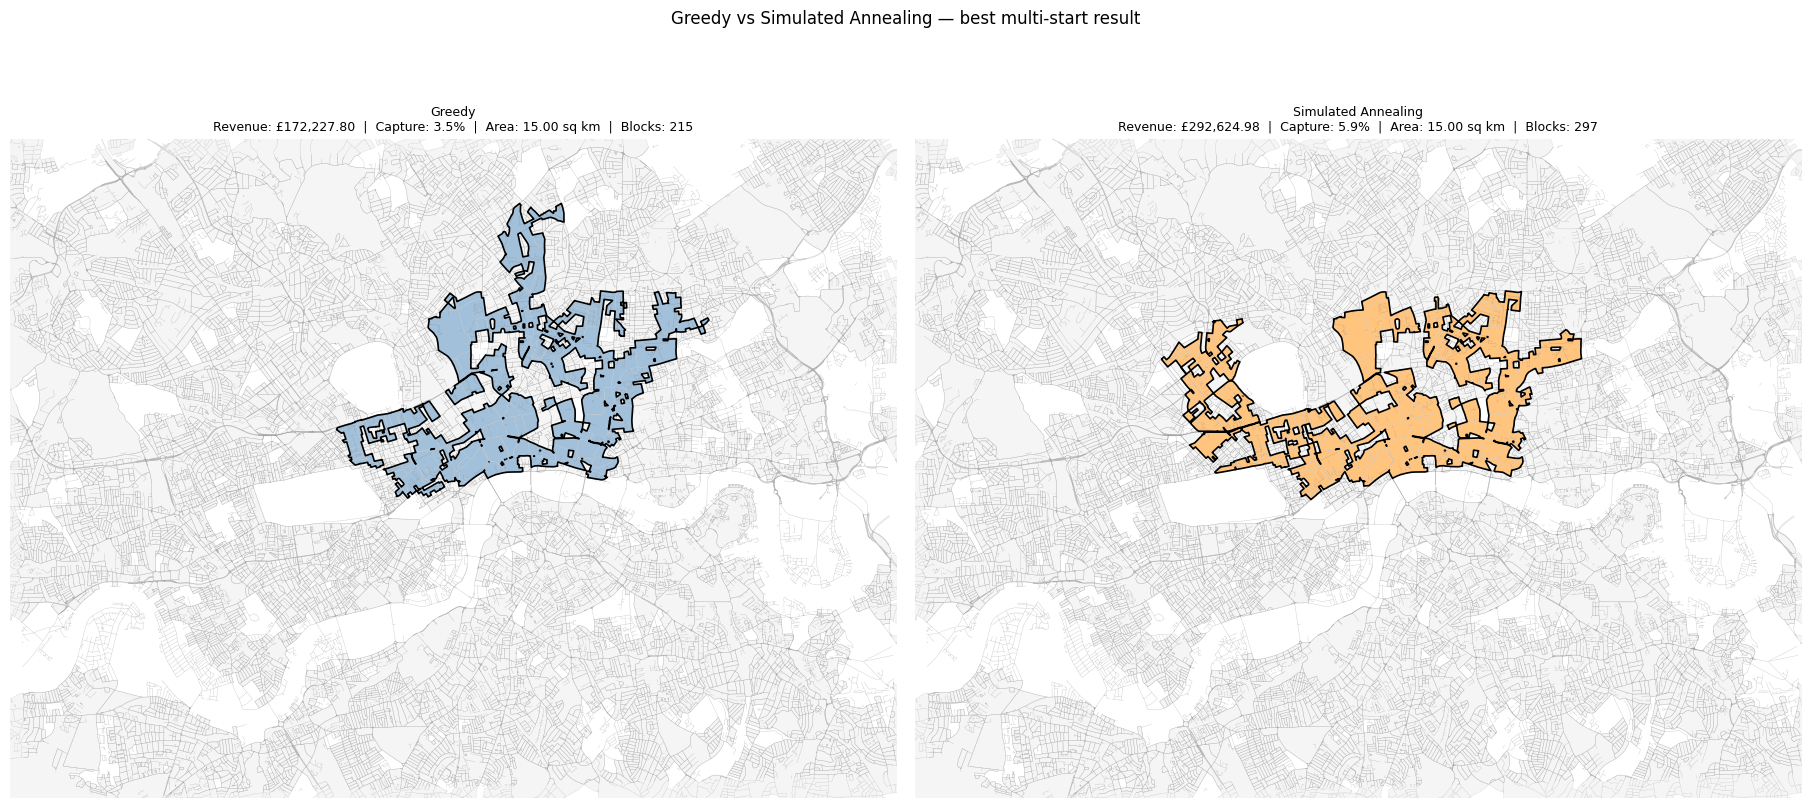

FINAL SUMMARY
Greedy    blocks= 215  area=15.00 sqkm  revenue=£172,227.80  capture=3.5%
SA        blocks= 297  area=15.00 sqkm  revenue=£292,624.98  capture=5.9%
------------------------------------------------------------
SA improvement : £+120,397.18  (+69.91%)


In [8]:
from shapely.geometry import box as shapely_box

# ── Project CENTER_BBOX to the map CRS ────────────────────────────────────────
_bbox_proj = (
    gpd.GeoSeries(
        [shapely_box(cfg.CENTER_BBOX[0], cfg.CENTER_BBOX[1],
                    cfg.CENTER_BBOX[2], cfg.CENTER_BBOX[3])],
        crs="EPSG:4326",
    )
    .to_crs(cfg.TARGET_CRS)
    .iloc[0]
)
xmin, ymin, xmax, ymax = _bbox_proj.bounds

fig, axes = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)

for ax, sel, rev, label, color in [
    (axes[0], g_sel,  g_rev,  "Greedy",              "steelblue"),
    (axes[1], sa_sel, sa_rev, "Simulated Annealing", "darkorange"),
]:
    blocks_in  = blocks_main[blocks_main["block_id"].isin(sel)]
    blocks_out = blocks_main[~blocks_main["block_id"].isin(sel)]
    poly       = unary_union(blocks_in.geometry)                                                                                                                                       

    roads.plot(ax=ax, linewidth=0.3, color="grey", alpha=0.4)                                                                                                                          
    blocks_out.plot(ax=ax, color="#f5f5f5", edgecolor="#cccccc", linewidth=0.2)
    blocks_in.plot(ax=ax, color=color, alpha=0.5, edgecolor="white", linewidth=0.3)                                                                                                    
                
    if poly.geom_type == "Polygon":                                                                                                                                                    
        gpd.GeoSeries([poly], crs=blocks_main.crs).boundary.plot(
            ax=ax, color="black", linewidth=1.2                                                                                                                                        
        )
                                                                                                                                                                                        
    # ── Zoom to central bbox ───────────────────────────────────────────────                                                                                                          
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)                                                                                                                                                            
                                                                                                                                                                                        
    area    = poly.area / 1e6
    capture = 100 * rev / total_rev                                                                                                                                                    
    ax.set_title(
        f"{label}\n"
        f"Revenue: £{rev:,.2f}  |  Capture: {capture:.1f}%  |  "
        f"Area: {area:.2f} sq km  |  Blocks: {len(sel)}",                                                                                                                              
        fontsize=9,
    )                                                                                                                                                                                  
    ax.set_axis_off()
                                                                                                                                                                                        
fig.suptitle("Greedy vs Simulated Annealing — best multi-start result", fontsize=12)
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────────                                                                                                      
print("=" * 60)
print("FINAL SUMMARY")                                                                                                                                                                 
print("=" * 60) 
for label, sel, rev in [("Greedy", g_sel, g_rev), ("SA", sa_sel, sa_rev)]:
    poly    = unary_union(blocks_main[blocks_main["block_id"].isin(sel)].geometry)                                                                                                     
    area    = poly.area / 1e6
    capture = 100 * rev / total_rev                                                                                                                                                    
    print(f"{label:<8}  blocks={len(sel):>4}  area={area:.2f} sqkm  "
        f"revenue=£{rev:>10,.2f}  capture={capture:.1f}%")                                                                                                                           
print("-" * 60) 
delta = sa_rev - g_rev                                                                                                                                                                 
print(f"SA improvement : £{delta:+,.2f}  ({100 * delta / g_rev:+.2f}%)")
print("=" * 60)                                                                                                                                                                        